In [1]:
import pickle
import io, time
from io import BytesIO
from IPython.display import display
import pickle, tarfile, random, re, requests
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
# pd.set_option('max_colwidth', -1)

import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression

import torch
from transformers import * # here introduces bert
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

# from allennlp.predictors.predictor import Predictor

In [2]:
# define the data structure and read data from file
#testing the code on IMDB, we'll reuse the code on all datasets later, make as reusable as possible

import requests, tarfile
from io import BytesIO
import pandas as pd
import pickle
import numpy as np
import random

class Dataset:
    def __init__(self, X, y, vec, df, moniker):
        """
        X: feature matrix;
        y: labels;
        vec: CountVectorizer
        df: dataframe
        feats: features from CountVectorizer
        moniker: reference name to the dataset
        """
        print('new dataset with %d records' % len(df))
        display(df.head(1))
        self.X = X
        self.y = y
        self.vec = vec
        self.df = df
        self.feats = np.array(vec.get_feature_names_out())
        self.moniker = moniker # name of the dataset
        

class SentenceEdit:
    def __init__(self, context, sentence_idx, remove_wd, label):
        """
        Remove a word from a sentence;
        E.g., 
            remove_wd: delicious 
            sentence: Love this book full of delicious foods
            context: Love this book full of  foods (at most 5 (window size) left and right words)
        """
        self.remove_wd = remove_wd
        self.context = context
        self.sentence_idx = sentence_idx
        
        self.label = label
        self.cluster_id = -1
      
    def __repr__(self):
        return '%s / %s / %s' % (self.remove_wd, str(self.label), self.context)
    
def get_IMDB():
    """
    Get IMDB movie reviews from the link;
    Sentences labeled as pos and neg
    
    """
    data_url = 'http://www.cs.cornell.edu/people/pabo/movie-review-data/rt-polaritydata.tar.gz'

    web_response = requests.get(data_url, stream=True)
    gz_file = web_response.content # Content in bytes from requests.get, see comments below why this is used.
    zipfile = tarfile.open(fileobj=BytesIO(gz_file))
    neg_file = zipfile.extractfile('rt-polaritydata/rt-polarity.neg')
    pos_file = zipfile.extractfile('rt-polaritydata/rt-polarity.pos')
    df = pd.DataFrame([{'label': -1, 'text': t.decode("cp437").strip() } for t in neg_file] +
                      [{'label': 1, 'text': t.decode("cp437").strip()} for t in pos_file])

    return df

In [3]:
def simple_vectorize(df):
    """
    Vectorize text
    """
    vec = CountVectorizer(min_df=5, binary=True, max_df=.8)
    X = vec.fit_transform(df.text)
    print(X.shape)
    y = df.label.values
    feats = np.array(vec.get_feature_names_out())
    
    return X, y, vec, feats

In [4]:
def print_coef(clf, feats, n=10, pattern=None):
    """
    sort and print words by coef stregth (abs(coef))
    """
    if len(clf.classes_) == 2:
        coefs = [-1*clf.coef_[0], clf.coef_[0]] # change the coef relation corresponding with each class
    else:
        coefs = clf.coef_

    for label, coef in zip(clf.classes_, coefs):
        print("\nTop features for class %s" % str(label))
        if pattern:
            # restrict to features matching pattern
            coef = coef.copy()
            coef[[i for i,s in enumerate(feats) if len(re.findall(pattern, s)) == 0]] = 0
        
        topi = coef.argsort()[::-1][:n]
        s = ' '.join('%s/%.2f' % (f,c) for f, c in zip(feats[topi], coef[topi]))
        print(s)
        
def get_top_terms(dataset, coef_thresh=.5, placebo_thresh=.5, C=1):
    """
    Fit classifier, print top-n terms;
    Top features (features have high coef): abs(coef) >= thresh
    Placebos (features have low coef): abs(coef) <= thresh
    """
    clf = LogisticRegression(class_weight='balanced', C=C, solver='lbfgs', max_iter=1000)
    clf.fit(dataset.X, dataset.y)
    
    print_coef(clf, dataset.feats, n=100)
    #print('dummy coef= %.3f' % clf.coef_[0][dataset.vec.vocabulary_[DUMMY_TERM]])
    
    top_feature_idx = np.where(abs(clf.coef_[0]) >= coef_thresh)[0]
    placebo_feature_idx = np.where(abs(clf.coef_[0]) <= placebo_thresh)[0]
    feature_coef = np.array([float("%.3f" % c) for c in clf.coef_[0]]) 
    
    return top_feature_idx, placebo_feature_idx, feature_coef

In [5]:
def get_wd_context(sentence, word, window=5):
    """
    Remove word from sentence and return context (at most 5 tokens before and after the word)
    E.g.,
        word: delicious 
        sentence: Love this book full of delicious foods
        context: Love this book full of ... foods (at most 5 (window size) left and right words)
        
    """
    word = word.lower()
    toks = sentence.split()
    
    for i, t in enumerate(toks):
        if re.search(r'(?i)\b%s\b' % word, t): # if find the word, then take left 5 and right 5 words
            s = ' '.join(toks[max(0, i-window):min(i+window+1, len(toks)-1)])
            return re.sub(r'(?i)\b%s\b' % word, ' ', s, re.IGNORECASE)
        
def remove_wd_from_sentences(X, sentences, labels, vec, remove_wd_list, exclude_sent_idx, window=5):
    """
    for each word to be removed
      for each treatment sentence (sentence containing this word)
        make a copy of the sentence with this word removed
        
    remove_wd_list:
        - top_words: abs(coef) > thresh
        - placebo_words: abs(coef) < thresh
    exclude_sent_idx:
        - sentences to exclude (sentences containing placebo_words should not contain top_words)
    
    X: feature matrix;
    sentences: a list of sentences containing keywords;
    labels: sentence labels;
    all_words: words to be removed;
    vec: CountVectorizer;
    window: number of tokens to keep before and after the removing word
    
    unk sentence: sentence with a specific word removed;
        E.g., "Love this book full of delicious foods"
              "Love this book full of ... foods"
                
    returns:
       unk_sentences: a list of SentenceEdit objects
       word2sentences: map from word to a list of SentenceEdit objects related with this word
       sentence_idx: list of processed sentence ids 
       
    """
    word2sentenceEdit = defaultdict(list)
    sentenceEdit_objs = []
    sentence_idx = []
    
    for word in remove_wd_list:
        wi = vec.vocabulary_[word]
        for sent_id in X[:,wi].nonzero()[0]: # sentences containing current word
            if(sent_id not in exclude_sent_idx): # not contain any top words
                wd_context = get_wd_context(sentences[sent_id], word, window) # context within window=5
                sEdit_obj = SentenceEdit(wd_context, sent_id, word, labels[sent_id])
                word2sentenceEdit[word].append(sEdit_obj)
                sentenceEdit_objs.append(sEdit_obj)
                sentence_idx.append(sent_id)
                
#     print('%d sentences with placebo terms\n' % len(unk_sentences))

    return sentenceEdit_objs, word2sentenceEdit, list(set(sentence_idx))

In [6]:
def get_original_sentences(df):
    """
    Original sentences without any word removed;
    Used when control case is not removing any word;
    """
    df['i_th'] = range(df.shape[0])
    original_sentEdit = []
    for ri, row in df.iterrows():
        sEdit_obj = SentenceEdit(row['text'], row['i_th'], '', row['label'])
        original_sentEdit.append(sEdit_obj)
        
    return original_sentEdit

In [7]:
def embed_one_sentence(sentence, sentence_model, tokenizer):
    """
    # bert_tokenizer.vocab_size
    # bert_tokenizer.tokenize(sentence)
    # bert_tokenizer.convert_tokens_to_ids('on')
    # bert_tokenizer.convert_ids_to_tokens(102)
    # each sentence is encoded as a 3072 vec: 768 * 4 (concat last four layers)
    """
    with torch.no_grad():
        # sentence_model returns (logit output layer, pooler_output, hidden states, attentions)
        hidden_states = sentence_model(torch.tensor([tokenizer.encode(sentence, add_special_tokens=True)]))[2]
        #last_four_layers = [hidden_states[i] for i in (-1, -2, -3, -4)]
        last_four_layers = [hidden_states[i] for i in (0,1,2,3)] # list of 4 element, each element is [1,16,768]
        # cast layers to a tuple and concatenate over the last dimension
        cat_hidden_states = torch.cat(tuple(last_four_layers), dim=-1) # [1,16,3072]
        cat_sentence_embedding = torch.mean(cat_hidden_states, dim=1).squeeze() # 3027
        #return(torch.mean(hidden_states[-1], dim=1).squeeze()) # average word embeddings in last layer
        return cat_sentence_embedding.numpy()                         # average last 4 layers
        
        
def embed_all_sentences(sentences, bert_tokenizer=None, sentence_model=None):
    """
    sentences: a list of SentenceEdit objects;
    Each sentence is a SentenceEdit object;
    Add embedding attribute for SentenceEdit object;
    """
    if not bert_tokenizer:
        bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        sentence_model = BertModel.from_pretrained('bert-base-uncased',output_hidden_states=True, output_attentions=True)
    
    for s in tqdm(sentences, disable=True):
        s.embedding = embed_one_sentence(s.context, sentence_model, bert_tokenizer)

In [8]:
def get_dataset_embeddings():
    """
    1. Get data from file and construct DataSet object
    2. Get top words, placebo words
    3. Edit sentences and get embeddings for edited sentences:
        Remove top words;
        Remove placebo words;
        Original sentences without edit;
    """
    random.seed(42)
    datasets = []
    for get_data_df, moniker, coef_thresh, placebo_thresh in [
            (get_IMDB, 'imdb', 1.0, 0.1),
        ]: 
        
        # Get data and show basic information
        df = get_data_df()
        X, y, vec, feats = simple_vectorize(df) # vectorize text
        ds = Dataset(X, y, vec, df, moniker) # construct dataset object
        
        print('%s dataset, %d instances' % (moniker,len(df)))
        print('Label distribution: %s' % str(Counter(y).items()))
        print('Feature matrix: %s' % str(X.shape))
        
        # Get top features 
        ds.top_feature_idx, ds.placebo_feature_idx, ds.coef = get_top_terms(ds, coef_thresh=coef_thresh, placebo_thresh=placebo_thresh, C=1)
        ds.top_features = feats[ds.top_feature_idx]
        ds.placebo_features = feats[ds.placebo_feature_idx]
        print('\n%d top terms: %d pos, %d neg\n' % (len(ds.top_features), len(np.where(ds.coef[ds.top_feature_idx]>0)[0]), len(np.where(ds.coef[ds.top_feature_idx]<0)[0])))
        print('\n%d placebo terms: %d pos, %d neg\n' % (len(ds.placebo_features), len(np.where(ds.coef[ds.placebo_feature_idx]>0)[0]), len(np.where(ds.coef[ds.placebo_feature_idx]<0)[0])))
        
        # Edit sentences (remove top features, placebo features, keep as it is) and get embedding representations
        
#         print('Edit sentences containing top words')                                                                   
        ds.topwd_sentObj_list, ds.topwd_sentObj_dict, topwd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.top_features,exclude_sent_idx=[])
        print('Edit %d sentences for top terms\n' % len(ds.topwd_sentObj_list))
        embed_all_sentences(ds.topwd_sentObj_list) 

#         print('Edit sentences containing placebo words')     
        ds.placebowd_sentObj_list, ds.placebowd_sentObj_dict, placebowd_sent_idx = remove_wd_from_sentences(X,df.text,df.label,vec,ds.placebo_features,topwd_sent_idx)
        print('Edit %d sentences for placebo terms\n' % len(ds.placebowd_sentObj_list))
        embed_all_sentences(ds.placebowd_sentObj_list) 
        
#         print('Original sentences convert to sentence edit object')
        ds.original_sentObj_list = get_original_sentences(df)
        print('%d original sentences')
        embed_all_sentences(ds.original_sentObj_list)    
        
        datasets.append(ds)
        
    return datasets


In [9]:
start = time.time()
datasets = get_dataset_embeddings()
end = time.time()
print((end-start)/60)

(10662, 4574)
new dataset with 10662 records


,label,text
0,-1,"simplistic , silly and tedious ."


imdb dataset, 10662 instances
Label distribution: dict_items([(-1, 5331), (1, 5331)])
Feature matrix: (10662, 4574)

Top features for class -1
boring/2.14 bore/2.12 dull/2.07 supposed/1.98 fails/1.96 badly/1.88 unless/1.78 waste/1.77 routine/1.77 junk/1.75 plodding/1.74 mindless/1.74 pie/1.73 unfunny/1.70 flat/1.67 worst/1.67 neither/1.66 generic/1.65 too/1.62 stupid/1.61 ill/1.60 disappointment/1.59 incoherent/1.58 suffers/1.57 intentions/1.56 wasn/1.53 superficial/1.53 mediocre/1.50 devoid/1.50 disguise/1.49 product/1.48 exhausting/1.48 stunt/1.47 uninspired/1.47 propaganda/1.44 stale/1.44 mess/1.44 tv/1.43 lacking/1.42 animal/1.42 benigni/1.42 schneider/1.42 sadly/1.41 tedious/1.41 artificial/1.41 inept/1.39 uneasy/1.36 lack/1.36 seagal/1.33 pretentious/1.33 hasn/1.32 sheridan/1.32 already/1.31 poorly/1.30 barely/1.30 bland/1.30 pointless/1.30 lifeless/1.29 unfortunately/1.29 unintentionally/1.28 choppy/1.27 conceived/1.27 college/1.27 pathetic/1.26 bits/1.26 none/1.26 god/1.26 bana

loading file vocab.txt from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json
loading file tokenizer.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.

Edit 13172 sentences for placebo terms



loading file vocab.txt from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at None
loading file tokenizer_config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json
loading file tokenizer.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json
loading file chat_template.jinja from cache at None
loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.

%d original sentences


loading configuration file config.json from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_attentions": true,
  "output_hidden_states": true,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.49.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at /Users/rahul/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd1

20.087777451674143


In [10]:
def find_matched_sentence(t_sentObj, c_sentObj_list, min_sim=.7):
    """
    For each treatment sentence (sentence contain a top word), find a matched sentence (sentences with similar contexts);
        
    Find the sentence with closest contexts:
    context_A = sentence_A - word_A
    context_B = sentence_B - word_B
    
    for context_A:
        sort similarity score of (context_A, all other contexts) in descending order
        if((sentence_A != sentence_B) and (word_A != word_B) and (cos(context_A,context_B)>0.7)):
            context_B is a match for context_A
    
    diff: difference between sentence_A.label - sentence_B.label
    """
    
    # similarity between current treatment context with all other contexts
    sims = cosine_similarity([t_sentObj.embedding],[c_sent.embedding for c_sent in c_sentObj_list])[0]
    
    match = None
    match_sim = 0
    for c_sentObj, sim in sorted(zip(c_sentObj_list, sims), key=lambda x: -x[1]): # find the first most similar match
        if((sim >= min_sim) and (c_sentObj.sentence_idx != t_sentObj.sentence_idx) and (c_sentObj.remove_wd != t_sentObj.remove_wd) and (not re.search(r'(?i)\b%s\b' % t_sentObj.remove_wd, c_sentObj.context))):
            match = c_sentObj
            match_sim = sim        
            break
            
    if match:
        diff = (t_sentObj.label - match.label)
    else:
        print('no match')
        diff = 0
#         diff = np.nan

    return diff, match_sim, match # [(match_sim, target_sentence)], [(match_sim,match)]


In [11]:
def calculate_ites_from_matched_sentences(ds_data, matchby='treat', min_sim=0.01):
    """
    For each treatment sentence (sentence contain a top word), find a matched sentence (sentences with similar contexts);
    
    t_sentObj_list: a list of SentenceEdit objects for sentences with top words removed
    c_sentObj_list: a list of SentenceEdit objects for sentences with top / placebo / '' words removed
    matchby = treat / control / placebo
    """
    t_sentObj_list = ds_data.topwd_sentObj_list
    
    if(matchby == 'treat'):
        c_sentObj_list = ds_data.topwd_sentObj_list
    elif(matchby == 'placebo'):
        c_sentObj_list = ds_data.placebowd_sentObj_list
    elif(matchby == 'control'):
        c_sentObj_list = ds_data.original_sentObj_list
    
    matched_pairs = []    
    for t_sentObj in tqdm(t_sentObj_list):
        ite_bylabel, sim, control_obj = find_matched_sentence(t_sentObj, c_sentObj_list, min_sim=min_sim)
            
        matched_pairs.append(
            {
                'term': t_sentObj.remove_wd,
                'sentence_id': t_sentObj.sentence_idx,
                'treat_obj': t_sentObj,
                'control_obj': control_obj, # this is an object             
                'similarity': sim,
                'difference': t_sentObj.embedding - control_obj.embedding, 
                'ite': ite_bylabel,
            }
        )
    return pd.DataFrame(matched_pairs)

In [12]:
datasets

In [13]:
# ds_imdb, ds_kindle, ds_toxic, ds_toxic_tw = datasets


start = time.time()
data_ites_byTreat = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='treat', min_sim=0.01)
    data_ites_byTreat.append(ds_data)
    
end = time.time()
print((end-start)/60)

  0%|          | 0/8777 [00:00<?, ?it/s]

5.529078098138173


In [14]:
start = time.time()

data_ites_byPlacebo = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='placebo', min_sim=0.01)
    data_ites_byPlacebo.append(ds_data)
    
end = time.time()
print((end-start)/60)

  0%|          | 0/8777 [00:00<?, ?it/s]

20.077484663327535


In [15]:
start = time.time()

data_ites_byControl = []
for ds_data in datasets:
    ds_data.ites = calculate_ites_from_matched_sentences(ds_data, matchby='control', min_sim=0.01)
    data_ites_byControl.append(ds_data)

end = time.time()
print((end-start)/60)

  0%|          | 0/8777 [00:00<?, ?it/s]

8.461559629440307


In [18]:
ds_imdb = datasets[0]


In [19]:
ds_imdb.df.shape, len(ds_imdb.top_features)

((10662, 3), 360)

In [20]:
from adjustText import adjust_text
import copy, io, time
from io import BytesIO
from itertools import combinations, cycle, product
from collections import Counter, defaultdict
from IPython.display import display
import math
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', -1)

import pickle, tarfile, random
from scipy.sparse import hstack, lil_matrix

from tqdm.notebook import tqdm

import sklearn
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize, scale, PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_recall_fscore_support

import warnings
warnings.filterwarnings("ignore")

In [21]:
from spurious_words import get_spurious_words


In [25]:
def load_matched_data(matchby='placebo'):
    """
    Load matched sentences from pre-calculated results;
    Sentences matched using different strategies:
        - treat / control / placebo
    
    """       
    if(matchby == 'treat'):
        [ds_imdb] = data_ites_byTreat
    elif(matchby == 'control'):
        [ds_imdb] = data_ites_byControl
    elif(matchby == 'placebo'):
        [ds_imdb] = data_ites_byPlacebo
    
    """
    Manually labeled spurious terms
    """
    spurious_words_map = get_spurious_words()
    for ds_data in [ds_imdb]:
        ds_data.BAD_POS = spurious_words_map[ds_data.moniker+'_bad_pos']
        ds_data.BAD_NEG = spurious_words_map[ds_data.moniker+'_bad_neg']
        ds_data.ALL_BAD = ds_data.BAD_POS + ds_data.BAD_NEG
        ds_data.DUMMY_TERM = 'xxxxx'

    
    return ds_imdb

In [26]:
def get_most_similar_match_with_label(term_df, label):
    """
    For a given label, check if there's a matched control sample have the same label
    In the word's ITE dataframe: 
        For each sentence, find a matched sample with the given label
        Sort in similarity descending order
    """
    has_match = False
    for s_obj in term_df.control_obj:
        if s_obj.label == label:
            has_match = True
    
    if has_match:
        return sorted([(sim,s_obj) for sim,s_obj in zip(term_df.similarity_scaled, term_df.control_obj) if s_obj.label==label], key=lambda i: i[0])[::-1][0][0]
    else:
        return 0

In [27]:
def scale_values(values_to_scale):
    """
    values to scale: 2d array, feature matrix, if it is 1-d, transfer to a 2d matrix with one column
    Separately scale each feature column to (0,1)
    """
    my_scaler = MinMaxScaler()
    
    if(len(values_to_scale.shape)==1):
        return my_scaler.fit_transform(values_to_scale.reshape(len(values_to_scale),1)).transpose()[0]
    elif(len(values_to_scale.shape)==2):
        return my_scaler.fit_transform(values_to_scale)

In [28]:
def compute_ite_features(ds_ite, groupby='term', min_df=10):
    """
    ds_ite:
        - dataframe of ['term','sentence_id','treat_obj','control_obj','similarity','difference', 'ite']
    Group ite dataframe by term;
    Each word is a sample, labeled as good/bad;
    Get feature representations for each word, features generated from term_ites (term_ites are matched sentences regarding that term).
    """
    
    ds_ite['similarity_scaled'] = scale_values(ds_ite.similarity.values)
    
    features_fromItes = []
    
    for term, term_df in ds_ite.fillna(0).groupby(groupby):
        # term and correpsonding term_df
        if len(term_df) >= min_df:
            features_fromItes.append({
                'term': '%s%s' % (term, '' if groupby=='term' else '-dummy'),

                'ite_abs_avg': abs(term_df.ite.mean()), # average over word ites (ite = treat label - control label)
                'ite_abs_top_5': abs(np.mean(sorted(np.abs(term_df.ite))[::-1][:5])), # top-5 highest abs(ite)

                'similarity_scaled_avg': term_df.similarity_scaled.mean(), # context similarity
                'similarity_scaled_top_5': np.mean(sorted(term_df.similarity_scaled)[::-1][:5]),
                'similarity_scaled_std': term_df.similarity_scaled.std(),
                'similarity_scaled_max': term_df.similarity_scaled.max(),
#                'closest_same_label_similarity_scaled': get_most_similar_match_with_label(term_df, 1 if ('-dummy' not in term_df.term.values[0] or term_df.coef.values[0] > 0) else -1),
#                'closest_diff_label_similarity_scaled': get_most_similar_match_with_label(term_df, -1 if ('-dummy' not in term_df.term.values[0] or term_df.coef.values[0] > 0) else 1),
                 'closest_pos_similarity_scaled': get_most_similar_match_with_label(term_df, 1),
                 'closest_neg_similarity_scaled': get_most_similar_match_with_label(term_df, -1),
#                 'similarity_scaled_min': term_df.similarity_scaled.min(),
#                 'similarity_scaled_max-min': term_df.similarity_scaled.max()-term_df.similarity_scaled.min(),                
                
                'ite_abs_top_5_by_sim': abs(np.mean([i[1] for i in sorted(zip(term_df.similarity_scaled, term_df.ite))[::-1][:5]])), # top-5 most similar 
                'ite_weighted_scaled': abs(np.average(term_df.ite.values, weights=term_df.similarity_scaled.values)), #ite weight by similarity

                'ite_x_similarity_scaled' : math.sqrt(abs(term_df.ite.mean()) * term_df.similarity_scaled.mean()),# avg_ite*avg_sim
                'ite_x_similarity_scaled_top_5' : math.sqrt(abs(term_df.ite.mean()) * np.mean(sorted(term_df.similarity_scaled)[::-1][:5])),

                'diff_mean_vec': np.mean(term_df.difference, axis=0), # mean of the terms' all diff vecs
                'diff_mean_abs': abs(np.mean(term_df.difference, axis=0).mean()),
                'diff_mean': np.mean(term_df.difference, axis=0).mean(), # mean over diff vecs, then mean over all dimensions
                
                'top_diff_mean': np.mean(sorted(np.mean(term_df.difference, axis=0))[::-1][:3]), # top-3 dims
                'diff_max_mean_abs': np.mean(np.max([np.abs(i) for i in term_df.difference.values], axis=0)), # abs max along each dim
                'diff_max_mean': np.mean(np.max([i for i in term_df.difference.values], axis=0)), # max along each dim
                'diff_min_mean': np.mean(np.min([i for i in term_df.difference.values], axis=0))        
            })
        
        
    return pd.DataFrame(features_fromItes)

In [29]:
def fit_pca(train_features_df, test_features_df, dim=40):
    """
    Separately scale train vec and test vec;
    Fit pca on :
        Training data;
        Concatenation of train and test;
    """
    
    pca = PCA(n_components=dim, random_state=42)
    
    scaled_train_diff_mean_vec = scale_values(np.array([i for i in train_features_df.diff_mean_vec.values]))
    
#     return pca.fit(scaled_train_diff_mean_vec) # pca only fit on training data
    scaled_test_diff_mean_vec = scale_values(np.array([i for i in test_features_df.diff_mean_vec.values]))
    
    pca.fit(np.vstack((scaled_train_diff_mean_vec,scaled_test_diff_mean_vec)))
    
    return pca

In [38]:
def set_term_coef(ites_df, X, y, feats):
    """
    Get coef for each term (terms that have ite dataframe);
    Coef as one of words' features;
    """
    clf = LogisticRegression(class_weight='balanced', C=1, solver='lbfgs', max_iter=1000)
    clf.fit(X, y)
    
    term2coef = {feats[i]:c for i,c in enumerate(clf.coef_[0])}
    ites_df['coef'] = [float("%.3f" % term2coef[t]) if t in term2coef else 0 for t in ites_df.term]   

In [31]:
def get_color(term, ds):
    """
    Different text color indicate different terms (good, bad, dummy)
    """
    try:
        if term == ds.DUMMY_TERM or 'dummy' in term:
            return 'blue'
        elif term in ds.BAD_POS:
            return 'green'
        elif term in ds.BAD_NEG:
            return 'red'
        else:
            return 'black'
    except:
        return 'yellow'
    
def plot_wdClf_prediction(features_df, ds, prob='in_domain'):
    """
    x-axis: coef;
    y-axis: p(y=good|word) from word classifier;
    if prob =='in-domain':
        y_axis = 'cv_prob'
    elif prob == 'out-domain':
        y_axis = 'domain_transfer_prob'
    """
    if(ds.moniker in ['toxic','toxic_tw']): # only consider pos/toxic class in toxic dataset
        lb_list = ['pos']
    else:
        lb_list = ['pos','neg']
    
    for label in lb_list:
        plt.figure(figsize=(12,8))
        show_feat_df = features_df.dropna()
        if(label=='pos'):
            show_feat_df = show_feat_df[show_feat_df.coef > 0]
        else:
            show_feat_df = show_feat_df[show_feat_df.coef < 0]
#         itesi = itesi[itesi.coef > 0] if label=='pos' else itesi[itesi.coef < 0]
        xcol = 'coef'
        
        if prob =='in_domain':
            ycol = 'cv_prob'
        elif prob == 'out_domain':
            ycol = 'domain_transfer_prob'

        x_vals = show_feat_df[xcol]
        y_vals = show_feat_df[ycol]
        plt.scatter(x_vals, y_vals, alpha=.5)    
        
        text = [plt.text(xv,yv,term, ha='center', color=get_color(term, ds), alpha=.8, va='center')
            for xv,yv,term in zip(x_vals, y_vals, show_feat_df.term)]
        
        plt.axhline(.5)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(ds.moniker+" | text color: (Blue: dummy; Green: bad_pos, red: bad_neg, black: others;)")
        adjust_text(text, lim=10) # slow
        plt.show()

In [45]:
def do_cv(X, y, n=5):
    """
    5-fold cross_validation for word classifier;
    class_weight = 'auto' VS 'balanced' VS 'None'
    """
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    kf = KFold(n_splits=5, random_state=42, shuffle=True)
    preds = np.zeros(len(y), y.dtype)
    probs = np.zeros(len(y), float)    
    
    for train, test in kf.split(X):
        clf.fit(X[train], y[train])
        preds[test] = clf.predict(X[test])
        probs[test] = clf.predict_proba(X[test])[:,1]        
    
    return preds, probs

In [42]:
def word_classifier(ds_src, ds_tar, show_src=True, use_coef=True, use_pca=True):
    """
    ds_src: source domain;
    ds_tar: target domain;
    ds_data.ites: :
        - dataframe of ['term','sentence_id','treat_obj','control_obj','similarity','difference', 'ite']
    
    Represent each word with following features: 
    - 18 ite features;
    - 1 coef feature (optional);
    - 40 pca features (optional, using pca features complex the problem);
                    
    Binary word classifier to distinguish between GOOD (1) and BAD (-1) words:
    - Self evaluation;
    - Same domain cross validation (ds_src == ds_tar);
    - Domain transfer: fit classifier on source domain, and predict on target domain (ds_src != ds_tar);
    
    """
    
    # get 19 ite features + 1 coef feature
    src_features_df = compute_ite_features(ds_src.ites)
    tar_features_df = compute_ite_features(ds_tar.ites)
    
    set_term_coef(src_features_df, ds_src.X, ds_src.y, ds_src.feats)
    set_term_coef(tar_features_df, ds_tar.X, ds_tar.y, ds_tar.feats)
         
#     print(src_features_df.shape, tar_features_df.shape)
    
    # For toxic dataset, only check BAD_POS and GOOD_POS
    if(ds_src.moniker in ['toxic','toxic_tw']): 
        src_features_df = src_features_df[src_features_df['coef']>0]
        tar_features_df = tar_features_df[tar_features_df['coef']>0]
        print("Source: (%s, %d), target: (%s, %d), only use pos(toxic) words" % (ds_src.moniker,src_features_df.shape[0],ds_tar.moniker,tar_features_df.shape[0]))
        
    
    # 40 PCA features from mean vectors of embedding differences
    if(use_pca):
        dim=40
        fitted_pca = fit_pca(src_features_df, tar_features_df, dim)

        src_pca = fitted_pca.transform(scale_values(np.array([i for i in src_features_df.diff_mean_vec.values])))
        src_pca_df = pd.DataFrame(src_pca, columns=['pca_%d' % i for i in range(dim)])
        src_features_df = pd.concat([src_features_df.reset_index(drop=True, inplace=False), src_pca_df], axis=1)
        feats_colm = np.array([i for i in src_features_df.columns if i not in ['diff_mean_vec', 'term', 'good_term', 'label']])
        X_src = scale(src_features_df[feats_colm])

        tar_pca = fitted_pca.transform(scale_values(np.array([i for i in tar_features_df.diff_mean_vec.values])))
        tar_pca_df = pd.DataFrame(tar_pca, columns=['pca_%d' % i for i in range(dim)])
        tar_features_df = pd.concat([tar_features_df.reset_index(drop=True, inplace=False), tar_pca_df], axis=1)
        X_tar = scale(tar_features_df[feats_colm])
    else:
        feats_colm = np.array([i for i in src_features_df.columns if i not in ['diff_mean_vec', 'term', 'good_term', 'label']])
        X_src = scale(src_features_df[feats_colm])
        X_tar = scale(tar_features_df[feats_colm])
#         print(X_src.shape)
    
    # Assign label: bad_term assign -1, others assign 1
    y_src = np.array([-1 if term in ds_src.ALL_BAD else 1 for term in src_features_df.term] )
    src_features_df['label'] = y_src
    print(ds_src.moniker+" (source), bad VS good terms: ",sorted(Counter(y_src).items()))
    
    # fit word classifier
    wd_clf = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=1000)
    wd_clf.fit(X_src, y_src)

    # show important features of word classifier
    print('\nFeature importance: ',sorted([item for item in zip([float("%.2f" % c) for c in wd_clf.coef_[0]],feats_colm)]))
    
    # self evaluation (train and predict on same data)
    print("\n%s --> %s, self-evaluation:\n" % (ds_src.moniker, ds_src.moniker))
    print(classification_report(y_src, wd_clf.predict(X_src)))

    # cross validation on source domain
    y_src_pred_lb, y_src_pred_prob = do_cv(X_src, y_src, n=10)
    print("\n%s --> %s, 5-fold cross validation, auc: %.3f:" % (ds_src.moniker, ds_src.moniker, 
                                                                roc_auc_score(y_src, y_src_pred_prob)))
    src_report = classification_report(y_src, y_src_pred_lb, output_dict=True)
    print(classification_report(y_src, y_src_pred_lb))
    
    src_features_df['cv_prob'] = y_src_pred_prob 
    ds_src.term_df = src_features_df # 59 features + term + label
    
    if(show_src):
        plot_wdClf_prediction(src_features_df, ds_src, prob='in_domain') # oob probas
        
    # domain transfer: train on words from source domain, predict on words from target domain
    y_tar = np.array([-1 if term in ds_tar.ALL_BAD else 1 for term in tar_features_df.term] )
    tar_features_df['label'] = y_tar
    print(ds_tar.moniker+" (target), bad VS good terms: ",sorted(Counter(y_tar).items()))
    
    y_tar_pred_lb = wd_clf.predict(X_tar)
    y_tar_pred_prob = wd_clf.predict_proba(X_tar)[:,1]
    print("\n%s --> %s, domain transfer, auc: %.3f: \n" % (ds_src.moniker, ds_tar.moniker, 
                                                           roc_auc_score(y_tar, y_tar_pred_prob)))
    tar_report = classification_report(y_tar, y_tar_pred_lb, output_dict=True)
    print(classification_report(y_tar, y_tar_pred_lb))
    
    y_tar_cv_pred_lb, y_tar_cv_pred_prob = do_cv(X_tar, y_tar, n=10)
    tar_features_df['cv_prob'] = y_tar_cv_pred_prob
    tar_features_df['domain_transfer_prob'] = y_tar_pred_prob
    ds_tar.term_df = tar_features_df
    plot_wdClf_prediction(tar_features_df, ds_tar, prob='out_domain')
    
    return ds_src, ds_tar, src_report, tar_report

In [46]:
def run_word_classifier(matchby):
    """
    For document classification task
    """
#     file_map = {m:i for i,m in enumerate(['','treat','control','placebo'])}
#     folder = path+'V_' + str(file_map[matchby]) + '_' + matchby # V_1_treat, V_2_control, V_3_placebo
    
    folder = 'data/'
    
    ds_imdb= load_matched_data(matchby = matchby)
    
    ds_prob = [] # ds_data could update in later change
    In_domain_result = {}
    Out_domain_result = {}
    
    for ds_src, ds_tar in zip([ds_imdb],[ds_imdb]):
        print(ds_src.moniker,'-->', ds_tar.moniker)
        
        ds_src, ds_tar, src_report, tar_report = word_classifier(ds_src, ds_tar, show_src=False, use_coef=True, use_pca=False)
        ds_prob.append(copy.deepcopy(ds_tar))
        
        In_domain_result[ds_src.moniker] = src_report
        Out_domain_result[ds_tar.moniker] = tar_report
    
      
#    pickle.dump(ds_prob,open(folder+'/datasets_with_term_prob.pickle','wb'))

#     pickle.dump(src2src_prob,open(folder+'/datasets_src2src_5cv_prob.pickle','wb'))
    
    return In_domain_result, Out_domain_result

imdb --> imdb
imdb (source), bad VS good terms:  [(-1, 89), (1, 173)]

Feature importance:  [(-0.7, 'diff_mean_abs'), (-0.64, 'closest_neg_similarity_scaled'), (-0.64, 'ite_weighted_scaled'), (-0.48, 'diff_mean'), (-0.41, 'diff_min_mean'), (-0.38, 'closest_pos_similarity_scaled'), (-0.22, 'diff_max_mean_abs'), (-0.17, 'ite_abs_top_5'), (-0.1, 'diff_max_mean'), (0.01, 'similarity_scaled_top_5'), (0.05, 'top_diff_mean'), (0.1, 'ite_abs_top_5_by_sim'), (0.21, 'ite_x_similarity_scaled'), (0.22, 'coef'), (0.29, 'ite_abs_avg'), (0.43, 'ite_x_similarity_scaled_top_5'), (0.56, 'similarity_scaled_std'), (0.84, 'similarity_scaled_max'), (0.87, 'similarity_scaled_avg')]

imdb --> imdb, self-evaluation:

              precision    recall  f1-score   support

          -1       0.56      0.73      0.63        89
           1       0.84      0.71      0.76       173

    accuracy                           0.71       262
   macro avg       0.70      0.72      0.70       262
weighted avg       0.74   

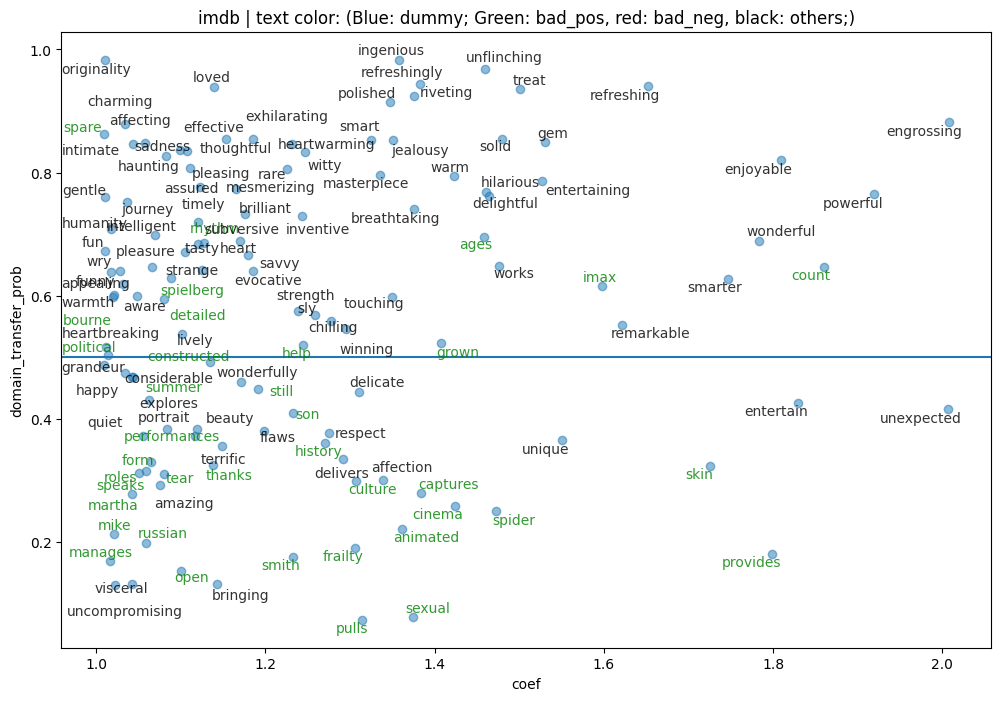

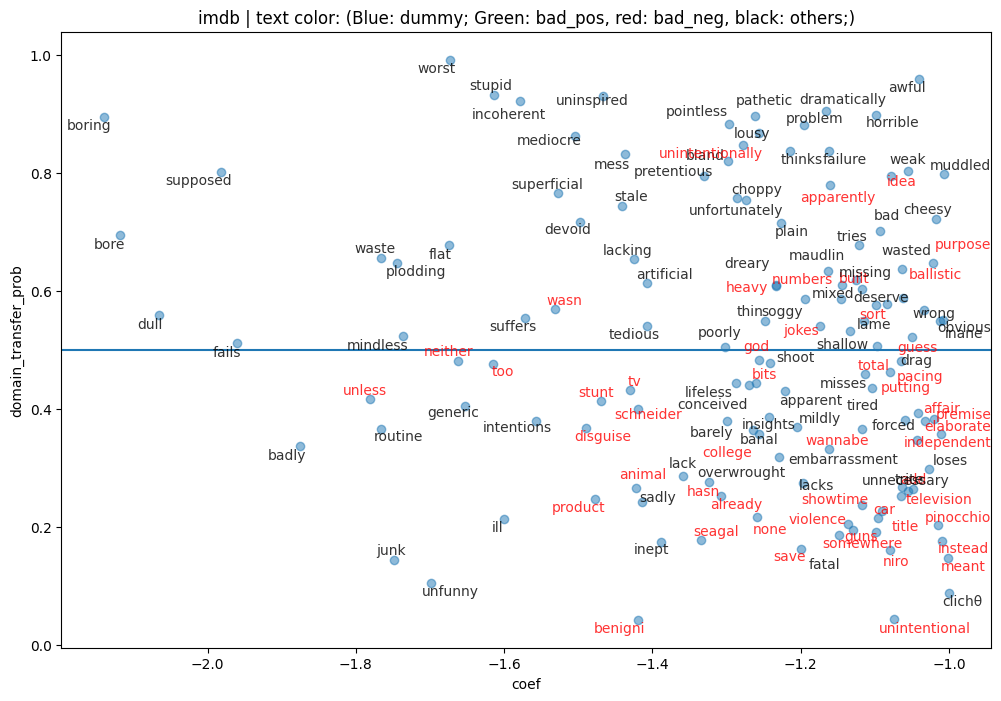

In [47]:
treat_in_domain_result, treat_out_domain_result = run_word_classifier(matchby='treat')


In [50]:
def run_word_classifier2(matchby):
    """
    For document classification task
    """
#     file_map = {m:i for i,m in enumerate(['','treat','control','placebo'])}
#     folder = path+'V_' + str(file_map[matchby]) + '_' + matchby # V_1_treat, V_2_control, V_3_placebo
    
    folder = 'data/'
    
    ds_imdb= load_matched_data(matchby = matchby)
    
    ds_prob = [] # ds_data could update in later change
    In_domain_result = {}
    Out_domain_result = {}
    
    for ds_src, ds_tar in zip([ds_imdb],[ds_imdb]):
        print(ds_src.moniker,'-->', ds_tar.moniker)
        
        ds_src, ds_tar, src_report, tar_report = word_classifier(ds_src, ds_tar, show_src=False, use_coef=True, use_pca=False)
        ds_prob.append(copy.deepcopy(ds_tar))
        
        In_domain_result[ds_src.moniker] = src_report
        Out_domain_result[ds_tar.moniker] = tar_report
    
    return ds_prob

imdb --> imdb
imdb (source), bad VS good terms:  [(-1, 89), (1, 173)]

Feature importance:  [(-0.7, 'diff_mean_abs'), (-0.64, 'closest_neg_similarity_scaled'), (-0.64, 'ite_weighted_scaled'), (-0.48, 'diff_mean'), (-0.41, 'diff_min_mean'), (-0.38, 'closest_pos_similarity_scaled'), (-0.22, 'diff_max_mean_abs'), (-0.17, 'ite_abs_top_5'), (-0.1, 'diff_max_mean'), (0.01, 'similarity_scaled_top_5'), (0.05, 'top_diff_mean'), (0.1, 'ite_abs_top_5_by_sim'), (0.21, 'ite_x_similarity_scaled'), (0.22, 'coef'), (0.29, 'ite_abs_avg'), (0.43, 'ite_x_similarity_scaled_top_5'), (0.56, 'similarity_scaled_std'), (0.84, 'similarity_scaled_max'), (0.87, 'similarity_scaled_avg')]

imdb --> imdb, self-evaluation:

              precision    recall  f1-score   support

          -1       0.56      0.73      0.63        89
           1       0.84      0.71      0.76       173

    accuracy                           0.71       262
   macro avg       0.70      0.72      0.70       262
weighted avg       0.74   

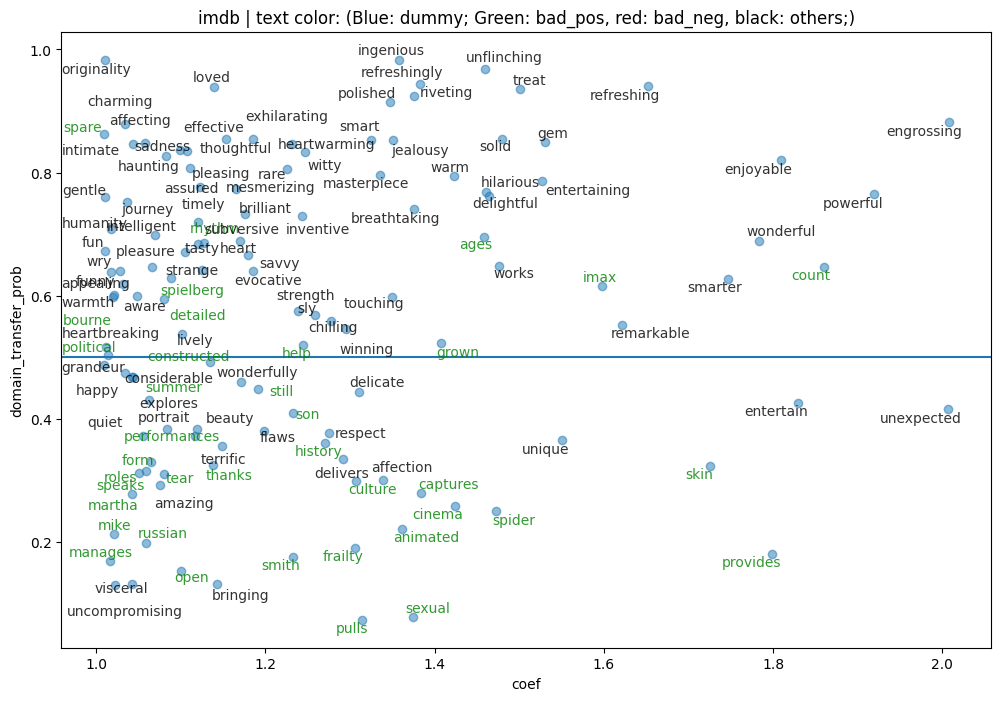

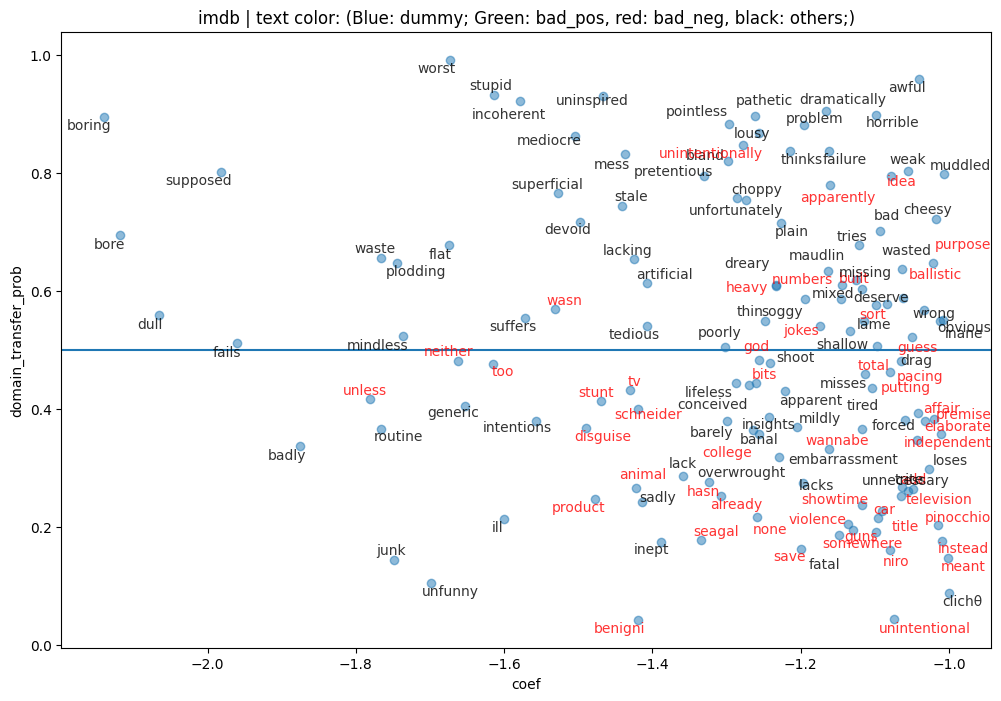

In [51]:
ds_data = run_word_classifier2(matchby='treat')

In [56]:
imdb_good_pos = ds_data[0].term_df[(ds_data[0].term_df.label==1) & (ds_data[0].term_df.coef>0)]
imdb_good_neg = ds_data[0].term_df[(ds_data[0].term_df.label==1) & (ds_data[0].term_df.coef<0)]
imdb_bad_pos = ds_data[0].term_df[(ds_data[0].term_df.label==-1) & (ds_data[0].term_df.coef>0)]
imdb_bad_neg = ds_data[0].term_df[(ds_data[0].term_df.label==-1) & (ds_data[0].term_df.coef<0)]
imdb_good_pos.shape, imdb_good_neg.shape, imdb_bad_pos.shape, imdb_bad_neg.shape

((88, 24), (85, 24), (38, 24), (51, 24))

In [57]:
imdb_good_pos.sort_values(by=['coef'],ascending=False).head(20)


,term,ite_abs_avg,ite_abs_top_5,similarity_scaled_avg,similarity_scaled_top_5,similarity_scaled_std,similarity_scaled_max,closest_pos_similarity_scaled,closest_neg_similarity_scaled,ite_abs_top_5_by_sim,...,diff_mean_abs,diff_mean,top_diff_mean,diff_max_mean_abs,diff_max_mean,diff_min_mean,coef,label,cv_prob,domain_transfer_prob
60,engrossing,0.424242,2.0,0.553980,0.725081,0.104928,0.833233,0.833233,0.607072,0.0,...,0.001277,-0.001277,0.223380,0.471612,0.407964,-0.405565,2.008,1,0.887994,0.881613
235,unexpected,0.800000,2.0,0.510437,0.621682,0.091883,0.693116,0.693116,0.622814,0.0,...,0.001078,-0.001078,0.257114,0.460547,0.390971,-0.390437,2.007,1,0.323721,0.415480
160,powerful,0.470588,2.0,0.567696,0.739636,0.103064,0.771903,0.751178,0.771903,0.4,...,0.000599,-0.000599,0.193026,0.492716,0.427722,-0.436176,1.919,1,0.704605,0.764833
62,entertain,0.166667,1.2,0.522313,0.635573,0.114918,0.716817,0.716817,0.688015,0.0,...,0.000932,-0.000932,0.329915,0.401657,0.317801,-0.316529,1.829,1,0.467420,0.426472
61,enjoyable,0.491803,2.0,0.576843,0.740097,0.093450,0.804604,0.804604,0.725288,0.4,...,0.000726,-0.000726,0.161516,0.506568,0.446346,-0.445787,1.809,1,0.840859,0.820022
256,wonderful,0.470588,2.0,0.577083,0.713003,0.080543,0.771674,0.741734,0.771674,0.8,...,0.000438,-0.000438,0.217778,0.463500,0.399727,-0.401429,1.783,1,0.758485,0.689807
193,smarter,0.666667,2.0,0.511384,0.617169,0.115284,0.702815,0.702815,0.580448,0.4,...,0.001157,-0.001157,0.336680,0.399182,0.316863,-0.322123,1.747,1,0.617875,0.626824
171,refreshing,0.782609,2.0,0.581297,0.728590,0.106634,0.787097,0.787097,0.689277,0.4,...,0.000120,-0.000120,0.221105,0.438672,0.368509,-0.369696,1.652,1,0.945676,0.940679
173,remarkable,0.303030,2.0,0.536932,0.684357,0.098279,0.730785,0.730785,0.646312,0.0,...,0.000822,-0.000822,0.246493,0.464832,0.398755,-0.397890,1.622,1,0.592136,0.552495
242,unique,0.086957,0.4,0.542034,0.647549,0.085079,0.685577,0.685577,0.665655,0.4,...,0.001253,-0.001253,0.248372,0.435332,0.364756,-0.366615,1.550,1,0.267596,0.365585


In [58]:
bad_pos = ['provides','imax','spider','cinema','sexual','tear','detailed','spielberg','russian','roles']
bad_neg = ['animal', 'tv', 'seagal', 'god', 'heavy', 'jokes','guns','violence','disguise','unintentionally']
good_pos = ['unexpected', 'engrossing','entertain','wonderful','smarter','unique','gem','treat','works','solid']
good_neg = ['boring','bore','dull','fails','routine','waste','mindless','unfunny','flat','generic']

In [59]:
from spurious_words import imdb_bad_pos, imdb_bad_neg, kindle_bad_pos, kindle_bad_neg, toxic_bad_pos, toxic_tw_bad_pos


In [60]:
len(set(imdb_bad_pos + imdb_bad_neg)), len(set(kindle_bad_pos + kindle_bad_neg)), len(set(imdb_bad_pos + imdb_bad_neg).intersection(set(kindle_bad_pos + kindle_bad_neg)))


(145, 154, 12)

In [61]:
len(set(toxic_bad_pos)), len(set(toxic_tw_bad_pos)), len(set(toxic_bad_pos).intersection(set(toxic_tw_bad_pos)))


(72, 139, 3)

In [62]:
import copy, io, time
from io import BytesIO
from itertools import combinations, cycle, product
from IPython.display import display
import math
import matplotlib.pyplot as plt
%matplotlib inline

import pickle, tarfile, random, re, requests
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', -1)

from tqdm.notebook import tqdm

import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_recall_fscore_support

import warnings
warnings.filterwarnings("ignore")

In [63]:
def load_data_with_term_prob():
    """
    load data that each term has a predicted probability of being genuine / (1-spurious);
    ds_data:
        - dataframe of [X, y, ..., ites, term_df]
        - ites is dataframe of matched sentence pairs: ['term','sentence_id','treat_obj','control_obj','similarity','difference','ite']
        - term_df is dataframe of feature representations (calculated from ites) for each term (e.g., ite features, coef, predicted_prob);
    
    use_prob: OOB (domain transfer), 5cv (same domain)
    Load data from file:
        ds.BAD_POS
        ds.BAD_NEG
        ds.term_df.predicted_prob
    """
    random.seed(42)
    

    ds_imdb = ds_data
    return ds_imdb

In [64]:
ds_imdb = load_data_with_term_prob()


In [66]:
def iter_options():
    # iterate over combinations of options.
    for use_probs in product(['oracle','feature_selection','domain_transfer','random'], [True, False]):
            if(not (use_probs=='random' and do_weight)):
                yield (use_probs, do_weight)
                        
def line_styles():
    """
    different line markers
    """
    markers = ['<', '+', '*',  'v', 's', 'D', 'P', 'o', '.','<', '>', '1', '+', 'X',
               '^', 's', '*', 'D', 'P', '.', 'v', '<', '>', '1',  'X']
    lines = ['-', '--', '-.', ':'] * 6
    
    return cycle(['%s%s' % (m, l) for l, m in zip(lines, markers)])

In [77]:
def sample_from_training_data(ds_data, train_idx, test_idx, test_majority_idx, test_minority_idx, axs):
    """
    In training set, sample n_majority = n_minority;
    Balance the effect of majority and minority groups in training set;
    Fit classifier on balanced training set and check performance on evaluation groups.
    """
    bad_term_stats, majority_idx, minority_idx = get_term_stats(ds_data,train_idx)
    
    smp_majority_idx = list(random.sample(majority_idx, len(minority_idx)))
    smp_train_idx = list(set(train_idx) - (set(majority_idx) - set(smp_majority_idx)))
    print("Train data distribution after sample majority group:",Counter(ds_data.y[smp_train_idx]))
    
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    clf.fit(ds_data.X[smp_train_idx], ds_data.y[smp_train_idx])
    
    group_score = {}
    for group, gp_idx in zip(['majority','minority','random'],[test_majority_idx, test_minority_idx, test_idx]):
        if(ds_data.moniker in ['Toxic comment','Toxic tweet']):
            group_score[group] = accuracy_score(ds_data.y[gp_idx],clf.predict(ds_data.X[gp_idx]))
        else:
            group_score[group] = roc_auc_score(ds_data.y[gp_idx],clf.predict_proba(ds_data.X[gp_idx]))
   
    # Horizontal line indicating the performance when training data is balanced 
    for i,group in enumerate(['majority','minority','random']):
        axs[i].axhline(group_score[group], alpha=0.8, linestyle='--')

In [68]:
def get_term_stats(df, data_idx):
    """
    Collect information about how often each word appears in majority and minority category.
    df: dataframe of each dataset
    data_idx: docs to sample from;
    
    For bad terms, sample the evaluation groups:
        Majority groups: (bad_pos, pos), (bad_neg, neg) 
        Minority groups: (bad_pos, neg), (bad_neg, pos)
    
    return: bad_term_stats, [term, n_docs, majority_idx, minority_idx, n_majority, n_minority, prob]
    """
    pos_idx = set(np.where(df.y==1)[0]).intersection(set(data_idx))
    neg_idx = set(np.where(df.y==-1)[0]).intersection(set(data_idx))
    
    bad_term_stats = []
    all_majority = set() # all majority docs regarding top terms
    all_minority = set() # all minority docs regarding top terms
    
    for ri, row_term in df.term_df.iterrows():
        if row_term['label'] == -1: # bad term
            term_i = df.vec.vocabulary_[row_term['term']] 
            term_docs = set(df.X[:,term_i].nonzero()[0])
            
            if row_term['coef'] < 0: # bad_neg words
                maj_idx = neg_idx & term_docs
                min_idx = pos_idx & term_docs
            else:                   # bad_pos_words
                maj_idx = pos_idx & term_docs
                min_idx = neg_idx & term_docs
                
            all_majority.update(maj_idx)
            all_minority.update(min_idx)
            
            bad_term_stats.append({
                'term': row_term['term'],
                'n_docs': len(term_docs),
                'majority_idx': maj_idx,
                'minority_idx': min_idx,
                'n_majority': len(maj_idx),
                'n_minority': len(min_idx),
                'cv_prob': row_term['cv_prob'],
                'domain_transfer_prob': row_term['domain_transfer_prob'],
            })
                
    return pd.DataFrame(bad_term_stats), all_majority, all_minority


def smp_equal_docs_per_term(ds_data, bad_term_stats, prohibited_idx, group, smp_size=2):
    """
    bad_term_stats: [term, n_docs, majority_idx, minority_idx, n_majority, n_minority, prob]
    group: majority / minority;
    
    Sample equal number of docs for each term;
    Term with lowest frequency has highest priority;
    
    smp_size:
        if > 0: specified smp_size
        elif < 0: calculated smp_size
        
    Return: sampled doc idx, dict[term] = sampled docs idx;
    """
    random.seed(42)
    
    if(smp_size == 0):
        smp_size = max(2, bad_term_stats['n_%s' % group].min()) # try to get at least this many samples per word.
        print("Sample size for %s: %d" % (group,smp_size))
    
    sampled_bad_terms = []
    sampled_indices = set() # docs that are being sampled
    
    # for each word
    for i, term_stat in bad_term_stats.sort_values('n_%s' % group).iterrows():
        if term_stat['n_%s' % group] > 0: # if have more than 0 docs in this group
            doc_idx = list(term_stat['%s_idx' % group])
            available_doc_idx = set(doc_idx) - set(sampled_indices) - set(prohibited_idx)
            smp_doc_idx = random.sample(available_doc_idx, min(smp_size,len(available_doc_idx)))
            sampled_indices.update(smp_doc_idx)
            sampled_bad_terms.append({'term':term_stat['term'],'%s_smp' % group :smp_doc_idx})
            
        else:
            continue
            
    return list(sampled_indices), pd.DataFrame(sampled_bad_terms)


def get_train_test_set(ds_data,smp_method='random'):
    """
    smp_method == random:
        1. random split 60% train, 40% test;
        2. sample majority and minority groups from test set;
        3. from majority and minority groups, sample equal number of docs for each term (specified by term_smp_size);
    smp_method != random:
        1. sample majority and minority groups from whole data set;
        2. from majority and minority groups, sample equal number of docs for each term (smp_size as min(2,min_docs per term));
        3. remaining data as training set;
    
    Return: train set, majority test set, minority test set;
    """
    if (smp_method == 'random'):
        # 1. random split
        train_idx, test_idx = train_test_split(np.arange(len(ds_data.y)), test_size=0.4, shuffle=True, random_state=42)
        # 2 get term stats in test set
        bad_term_stats, test_majority_idx, test_minority_idx = get_term_stats(ds_data, test_idx)
        # 3 sample equal number of docs per term from majority and minority
        prohibited_idx = test_majority_idx & test_minority_idx 
        minority_smp_idx, min_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='minority',smp_size=2)
        majority_smp_idx, maj_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='majority',smp_size=2)
        
    else:
        # 1 get term stats in whole data set
        bad_term_stats, all_majority_idx, all_minority_idx = get_term_stats(ds_data, np.arange(len(ds_data.y)))
        # 2 sample equal number of docs per term from majority and minority
        prohibited_idx = all_majority_idx & all_minority_idx 
        minority_smp_idx, min_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='minority',smp_size=0)
        majority_smp_idx, maj_bad_terms = smp_equal_docs_per_term(ds_data,bad_term_stats,prohibited_idx,group='majority',smp_size=0)
        # 3 remaining docs are train data
        train_idx = set(np.arange(len(ds_data.y))) - (set(majority_smp_idx) | set(minority_smp_idx))
    
    print('Sampled %d train instances; \ntest indices: (%d majority docs, %d terms), (%d minority docs, %d terms), intersection=%d' % 
          (len(train_idx), len(majority_smp_idx), maj_bad_terms.shape[0], 
           len(minority_smp_idx), min_bad_terms.shape[0],
           len(set(majority_smp_idx) & set(minority_smp_idx))))
    
    return list(train_idx), majority_smp_idx, minority_smp_idx, maj_bad_terms, min_bad_terms

In [78]:
def sort_terms_by_Prob(ds_data, feature_order):
    """
    sort terms by p(correct correlation) in ascending order
    """
    
    if (feature_order == 'feature_selection' or feature_order == 'feature_weighted'): # sort all important terms in probability increasing order
        terms_in_order = sorted(list(zip(ds_data.term_df.cv_prob, ds_data.term_df.term)))
        
    elif(feature_order == 'oracle'): # use_labels, randomly sort bad terms, intersection with term_df
        terms = list(set(ds_data.ALL_BAD.copy()).intersection(set(ds_data.term_df.term)))
        random.shuffle(terms)
        terms_in_order = list(zip([.1] * len(terms), terms))

    elif(feature_order == 'domain_transfer'):
        terms_in_order = sorted(list(zip(ds_data.term_df.domain_transfer_prob, ds_data.term_df.term)))
        
    elif (feature_order == 'random'): # randomly sort terms in ds_data.term_df
        terms_in_order = list(zip([.1] * len(ds_data.term_df.term), ds_data.term_df.term))
        random.shuffle(terms_in_order)
    else:
        print('Feature order not defined.')
    
    return terms_in_order

def remove_feats(X, indices):
    """
    set specified column in X to 0 use diagonal matrix multiplication
    """
    vals = np.ones(X.shape[1])
    vals[indices] = 0
    
    matrix = lil_matrix((len(vals), len(vals)))
    matrix.setdiag(vals)
    return X * matrix

def feature_selection(ds_data, train_idx, test_idx, feature_order='oracle',word_counts=None,verbose=False):
    """
    Sort terms in order (according to different methods):
        - oracle: sort human labeled bad terms in random order;
        - feature_selection: sort terms in probability(5-cv prediction) ascending order; 
        - domain_transfer: sort terms in probability(domain transfer prediction) ascending order; 
        - random: randomly sort good+bad terms;
        
    Increasingly remove/re-weight topn terms;
    """
    
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    clf.fit(ds_data.X[train_idx], ds_data.y[train_idx])
    
    terms_in_order = sort_terms_by_Prob(ds_data, feature_order)
    
    # only consider removing terms that actually appear in the specific test set.
    if word_counts is not None:
        terms_in_order = [t for t in terms_in_order if word_counts[ds_data.vec.vocabulary_[t[1]]]>0]
    
    all_coef = clf.coef_[0].copy()    
    score = []
    
    for torem in range(0, len(terms_in_order)+1): # tqdm(), increasingly remove/reweight terms
        try:
            terms_torem = terms_in_order[:torem]
            term_idx = np.array([ds_data.vec.vocabulary_[t[1]] for t in terms_torem])
            term_probs = np.array([t[0] for t in terms_torem])

            if len(term_idx) > 0: # more than 0 terms to change
                if feature_order == 'feature_weighted': 
                    # weight coef by proba, rather than removing.
                    factor = np.ones(len(all_coef))
                    factor[term_idx] = term_probs
                    clf.coef_[0] = all_coef.copy() * factor
                else: 
                    # feature selection by: oracle, p_spurious, random
                    clf.coef_[0][term_idx] = 0
                    # optionally retrain after removing feats.
                    # if retrain:
                         # interestingly, this usually hurts performance quite a bit on random sample.
                         # reason? classifier learns other terms as substitutes for the terms we removed,
                         # plus more overfitting...
                         # clf.fit(remove_feats(ds_data.X[train_idx], term_idx), ds_data.y[train_idx])
            # else:
                # print("Terms not in training data")

            pred_lb = clf.predict(ds_data.X[test_idx])
            pred_prob = clf.predict_proba(ds_data.X[test_idx])[:,1]
        
        except Exception as e:
            print('EXCEPTION %s' % str(e))
            traceback.print_exc()
            continue
            
        
        if(len(Counter(ds_data.y[test_idx]).keys())==1): # data only contain one class (toxic_wiki, toxic_tw)
            score.append(accuracy_score(ds_data.y[test_idx], pred_lb))
        else:
            score.append(roc_auc_score(ds_data.y[test_idx], pred_prob))
            
        if verbose and len(terms_torem) > 0:
            print('removed (%s,%.3f) score=%.3f' % (terms_torem[-1][1], terms_torem[-1][0],score[-1]))
        
    return score

In [92]:
def feature_selection_by_lexicon(ds_data, train_idx, test_idx, feature_order='lexicon',word_counts=None,verbose=False):
    """
    Using sentiment lexicon:
        - features in the lexicon are good terms;
        - features not in the lexicon are bad terms;
        - check classification result with only good terms;
    """
    sentiment_words = pd.read_csv('sentiment_lexicon.csv')
    
    clf = LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=1000)
    clf.fit(ds_data.X[train_idx], ds_data.y[train_idx])
    
    terms_torem = list(set(ds_data.vec.get_feature_names_out()) - set(sentiment_words.word.values))
    term_idx = np.array([ds_data.vec.vocabulary_[t] for t in terms_torem])
    
    clf.coef_[0][term_idx] = 0
    print("Removed %d terms, %d remained" % (len(terms_torem), len(ds_data.vec.vocabulary_)-len(terms_torem)))
    
    pred_lb = clf.predict(ds_data.X[test_idx])
    pred_prob = clf.predict_proba(ds_data.X[test_idx])[:,1]
        
    if(len(Counter(ds_data.y[test_idx]).keys())==1): # data only contain one class (toxic_wiki, toxic_tw)
        score = accuracy_score(ds_data.y[test_idx], pred_lb)
    else:
        score = roc_auc_score(ds_data.y[test_idx], pred_prob)

    if verbose and len(terms_torem) > 0:
        print('removed (%s,%.3f) score=%.3f' % (terms_torem[-1][1], terms_torem[-1][0],score[-1]))
    
    return score, terms_torem


In [93]:
def feature_selection_for_doc_classification(ds_data,axs_list,sample_by='random'):
    """
    ds_data: with p(genuine|term) by same domain cross validation and domain transfer;
    
    sample_by: 
        - random: random split first, and then sample minority and majority
        - priority: sample minority and majority first
        
    Document classification using different feature selection methods:
    - Perform feature selection on each evaluation group:
        - majority
        - minority
        - test set
      
    - feature selection strategies:
        - oracle
        - rank by probability from 5-cv: feature_selection, feature_weighted
        - rank by probability from domain_transfer
        - randomly rank good+bad terms
    """
    print("\n",ds_data.moniker)
    random.seed(42)
    
    train_idx, majority_idx, minority_idx, maj_bad_terms, min_bad_terms = get_train_test_set(ds_data,sample_by)
    test_idx = minority_idx + majority_idx
    
    print("Train distribution:",Counter(ds_data.y[train_idx]))
    print("Test distribution:",Counter(ds_data.y[test_idx]))
    print("Majority distribution:",Counter(ds_data.y[majority_idx]))
    print("Minority distribution:",Counter(ds_data.y[minority_idx]))
    
    
    # downsampling training to ensure majority = minority
#     sample_from_training_data(ds_data, train_idx, test_idx, majority_idx, minority_idx, axs_list) #, p_axs
    
    # list of word frequency [0,1,0,...]
    word_counts = ds_data.X[test_idx].sum(axis=0).A1    
    linecycler = line_styles()
    
    for mi,method in enumerate(['oracle','feature_selection','feature_weighted','domain_transfer','random','lexicon']):
        
        if(method != 'lexicon'):
            marker = next(linecycler) # each method corresponds to one line style

            # majority
            scores_for_majority = feature_selection(ds_data, train_idx, majority_idx, method, word_counts) # bad_terms=list(maj_bad_terms['term'].values
            axs_list[0].plot(np.arange(len(scores_for_majority)), scores_for_majority, marker, markersize=12,
                                                           linewidth=2, alpha=.6, label=method, markevery=10) 

            # minority
            scores_for_minority = feature_selection(ds_data, train_idx, minority_idx, method, word_counts)
            axs_list[1].plot(np.arange(len(scores_for_minority)), scores_for_minority, marker, markersize=12,
                                                           linewidth=2, alpha=.6, label=method, markevery=10)

            # test
            scores_for_test = feature_selection(ds_data, train_idx, test_idx, method, word_counts)
            axs_list[2].plot(np.arange(len(scores_for_test)), scores_for_test, marker, markersize=12,
                                                           linewidth=2, alpha=.6, label=method, markevery=10)
        
        else:
            print("Majority:", feature_selection_by_lexicon(ds_data, train_idx, majority_idx, method, word_counts))
            print("Minority:", feature_selection_by_lexicon(ds_data, train_idx, minority_idx, method, word_counts))
            print('Test:',feature_selection_by_lexicon(ds_data, train_idx, test_idx, method, word_counts))


In [94]:
def evaluate_feature_selection(task='sentiment',sample_by='random'):
    """
    task == sentiment | toxic
    sample_by == random | priority
    """
    path = 'data/'

    [ds_imdb] = load_data_with_term_prob()
    
    ds_imdb.moniker = 'IMDB'
        
    if task == 'sentiment':
        datas = [ds_imdb]
        score = 'AUC'
        print()
    fig, axs = plt.subplots(2,3,figsize=(18,14),sharex=False,sharey='row')
    axs = axs.flatten()
    p_i = 0
    
    for ds_data in datas:
        feature_selection_for_doc_classification(ds_data,[axs[p_i+0],axs[p_i+1],axs[p_i+2]],sample_by)
        
        axs[p_i+0].set_ylabel(ds_data.moniker+" (%s)" % score, fontsize=25)
        axs[p_i+0].yaxis.set_tick_params(labelsize=25)        
        p_i += 3
        
    
    fig.suptitle('Number of features removed', fontsize=26, x=0.5, y=.02, va='bottom')    

    axs[0].set_title("Majority", fontsize=30)
    axs[1].set_title("Minority", fontsize=30)
    axs[2].set_title("All",fontsize=30)
    
    plt.subplots_adjust(wspace=0.05, hspace=.2)
    
    # reference: https://jakevdp.github.io/PythonDataScienceHandbook/04.10-customizing-ticks.html
    axs[0].yaxis.set_major_locator(plt.MaxNLocator(5))
    axs[3].yaxis.set_major_locator(plt.MaxNLocator(5))
    
    for a in axs:
        a.xaxis.set_tick_params(labelsize=25, rotation=90)
        a.xaxis.set_major_locator(plt.MaxNLocator(5)) # maximum number of ticks to displayed
        a.yaxis.grid(which='major') # add grid on yaxis
        
    if task=='sentiment':
        axs[5].legend(loc='lower center', fontsize=24) # 5
#         fig.savefig('doc_clf_sentiment_A.pdf', bbox_inches='tight')
    else:
        axs[4].legend(loc='lower center', fontsize=24)
#         fig.savefig('doc_clf_toxic_A.pdf', bbox_inches='tight')
    plt.show()


Subgroup Analysis:
Minority Group (contains spurious markers):
  Number of samples: 456
  Accuracy: 0.9100877192982456
  AUC: 0.9479470648116728




 IMDB
Sample size for minority: 2
Sample size for majority: 7
Sampled 9904 train instances; 
test indices: (622 majority docs, 89 terms), (136 minority docs, 77 terms), intersection=0
Train distribution: Counter({1: 4990, -1: 4914})
Test distribution: Counter({-1: 417, 1: 341})
Majority distribution: Counter({-1: 357, 1: 265})
Minority distribution: Counter({1: 76, -1: 60})
Removed 3239 terms, 1335 remained
Majority: (0.7336821521061255, ['think', 'pile', 'essence', 'elsewhere', 'explore', 'bittersweet', 'expectations', 'lives', 'ponder', 'teeth', 'common', 'amateurish', 'dealing', 'area', 'evoke', 'aimed', 'com', 'wears', 'performers', 'sustains', 'control', 'harvard', 'charms', 'bruckheimer', 'plan', 'nights', 'directing', 'predecessors', 'social', 'wife', 'cage', 'creativity', 'bartleby', 'were', 'possession', 'deliciously', 'camp', 'immensely', 'amount', 'michel', 'noir', 'bears', 'reflection', 'turning', 'sequels', 'grade', 'remembering', 'eventual', 'mary', 'follows', 'mid', 'f

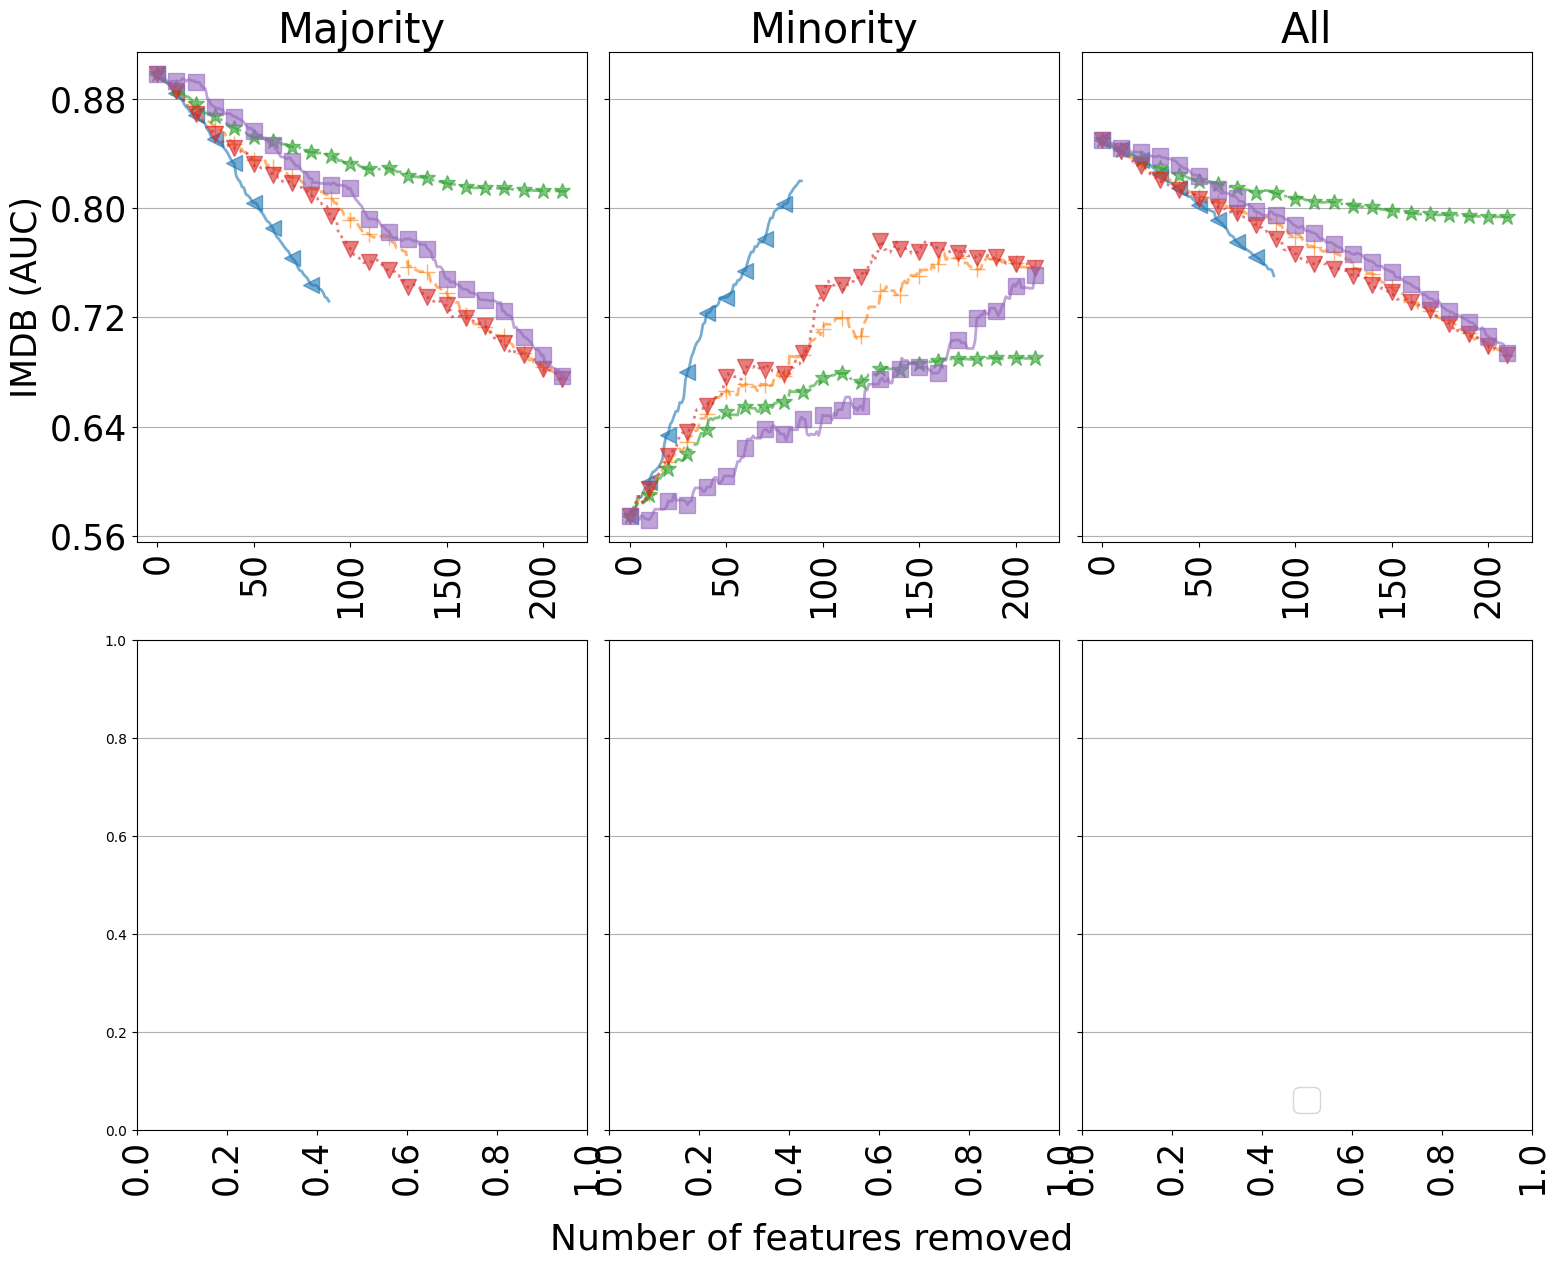

In [95]:
evaluate_feature_selection(task='sentiment',sample_by='priority')
